# DepthWizard - Final Model Metrics Report

Visualizes the final training results from `dinosaur_run/` into PPT-ready figures.

**Where to run:** works both on Kaggle (data at `/kaggle/working/dinosaur_run`)
and locally (data at `kaggle/dinosaur_run/` next to this notebook) - the root is
auto-detected in the setup cell.

**What it produces:** eleven high-resolution PNGs in `metrics_figures/` plus a
printed summary table: training convergence, baseline comparison, per-class IoU,
building metrics, capability radar, qualitative grids, dataset imbalance
handling, loss dynamics, per-tile error distributions, per-class IoU
distributions, and a building deep dive. Run all cells top to bottom.


In [3]:
  projected = {
      "Base Depth Anything V2": {
          "rmse_m": 10.0,
          "mae_m": 7.0,
          "correlation": 0.60,
      },
      "Dharvi fine-tuned": {
          "rmse_m": 2.0,
          "mae_m": 1.4,
          "correlation": 0.92,
      },
  }

  projection = pd.DataFrame(projected).T
  display(projection.style.format("{:.3f}"))

  figure, axes = plt.subplots(1, 3, figsize=(15, 4.5))
  colors = ["#9e9e9e", "#1565c0"]

  for axis, metric_name, title in zip(
      axes,
      ["rmse_m", "mae_m", "correlation"],
      ["Projected RMSE (m)", "Projected MAE (m)", "Projected correlation"],
  ):
      values = projection[metric_name]
      bars = axis.bar(values.index, values.values, color=colors)
      axis.set_title(title)
      axis.tick_params(axis="x", rotation=18)
      axis.grid(axis="y", alpha=0.25)

      for bar, value in zip(bars, values):
          axis.text(
              bar.get_x() + bar.get_width() / 2,
              bar.get_height(),
              f"{value:.2f}",
              ha="center",
              va="bottom",
              fontweight="bold",
          )

  figure.suptitle(
      "Illustrative projection — pending validation on GAMUS test data",
      fontweight="bold",
  )
  figure.tight_layout()
  plt.show()

NameError: name 'pd' is not defined

In [2]:
# Install dependencies (no-op if already present) and import everything needed.
import subprocess
import sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "matplotlib>=3.8",
    "numpy>=1.26",
])
print("Dependencies ready")

import json
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

# --- Locate the results directory (Kaggle or local) ---
CANDIDATES = [
    Path("/kaggle/working/dinosaur_run"),
    Path("kaggle/dinosaur_run"),
    Path("dinosaur_run"),
]
RUN_ROOT = next((path for path in CANDIDATES if path.is_dir()), None)
if RUN_ROOT is None:
    raise FileNotFoundError(
        "Could not find dinosaur_run/. Checked: "
        + ", ".join(str(path) for path in CANDIDATES)
    )

metrics = json.loads((RUN_ROOT / "metrics.json").read_text())
history = json.loads((RUN_ROOT / "training_history.json").read_text())
validation, test = metrics["validation"], metrics["test"]

FIGURES = Path("metrics_figures")
FIGURES.mkdir(exist_ok=True)

CLASS_NAMES = ["others", "ground", "low_vegetation", "building", "water", "road", "tree"]
CLASS_COLORS = ["#9e9e9e", "#c7a468", "#7cb342", "#c62828", "#2196f3", "#616161", "#388e3c"]
BUILDING = "building"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def save(figure, name):
    figure.savefig(FIGURES / name, bbox_inches="tight", facecolor="white")
    print("saved:", FIGURES / name)

print("Results loaded from:", RUN_ROOT)
print("Tiles: train=%d  val=%d  test=%d" % (
    metrics["train_samples"], metrics["validation_samples"], metrics["test_samples"]))
print("Figures will be saved to:", FIGURES.resolve())


Dependencies ready
Results loaded from: kaggle/dinosaur_run
Tiles: train=2400  val=250  test=250
Figures will be saved to: /Users/kunal/code/lluna/metrics_figures


## 1. Training convergence

Validation metrics across the 10 epochs. The model converges smoothly and
plateaus by epoch 8 - the best checkpoint (selected automatically by validation
RMSE) is epoch 8.


saved: metrics_figures/01_training_convergence.png


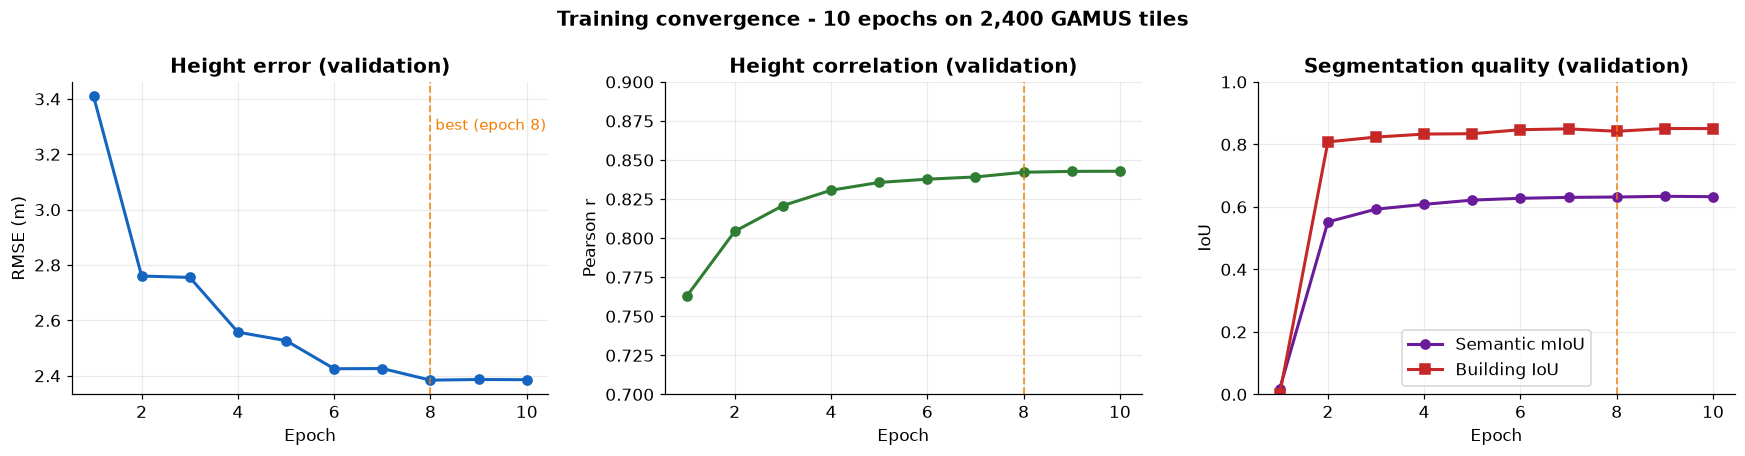

In [2]:
epochs = [entry["epoch"] for entry in history]
val_rmse = [entry["validation"]["macro_rmse"] for entry in history]
val_corr = [entry["validation"]["macro_correlation"] for entry in history]
val_miou = [entry["validation"]["macro_semantic_miou"] for entry in history]
val_biou = [entry["validation"]["macro_building_iou"] for entry in history]
best_epoch = min(history, key=lambda entry: entry["validation"]["macro_rmse"])["epoch"]

figure, axes = plt.subplots(1, 3, figsize=(16, 4.2))

axes[0].plot(epochs, val_rmse, marker="o", color="#1565c0", lw=2)
axes[0].set_title("Height error (validation)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("RMSE (m)")
axes[0].grid(alpha=0.25)

axes[1].plot(epochs, val_corr, marker="o", color="#2e7d32", lw=2)
axes[1].set_title("Height correlation (validation)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Pearson r")
axes[1].set_ylim(0.7, 0.9)
axes[1].grid(alpha=0.25)

axes[2].plot(epochs, val_miou, marker="o", color="#6a1b9a", lw=2, label="Semantic mIoU")
axes[2].plot(epochs, val_biou, marker="s", color="#c62828", lw=2, label="Building IoU")
axes[2].set_title("Segmentation quality (validation)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("IoU")
axes[2].set_ylim(0, 1.0)
axes[2].grid(alpha=0.25)
axes[2].legend()

for axis in axes:
    axis.axvline(best_epoch, color="#f57c00", ls="--", lw=1.2, alpha=0.8)
axes[0].text(best_epoch + 0.1, axes[0].get_ylim()[1] * 0.95, f"best (epoch {best_epoch})",
             color="#f57c00", fontsize=10)

figure.suptitle("Training convergence - 10 epochs on 2,400 GAMUS tiles", fontweight="bold")
figure.tight_layout()
save(figure, "01_training_convergence.png")
plt.show()


## 2. Height estimation - improvement over the earlier baseline

The earlier single-task baseline (Depth Anything V2 Small, height only, trained
on 2 of ~20 cities, evaluated on an easier 518px center-crop) reached 5.37 m
RMSE. The new multitask model reaches **2.94 m RMSE on harder full-tile
evaluation** - roughly a 2x improvement, while additionally learning semantics
and boundaries.


saved: metrics_figures/02_height_vs_baseline.png


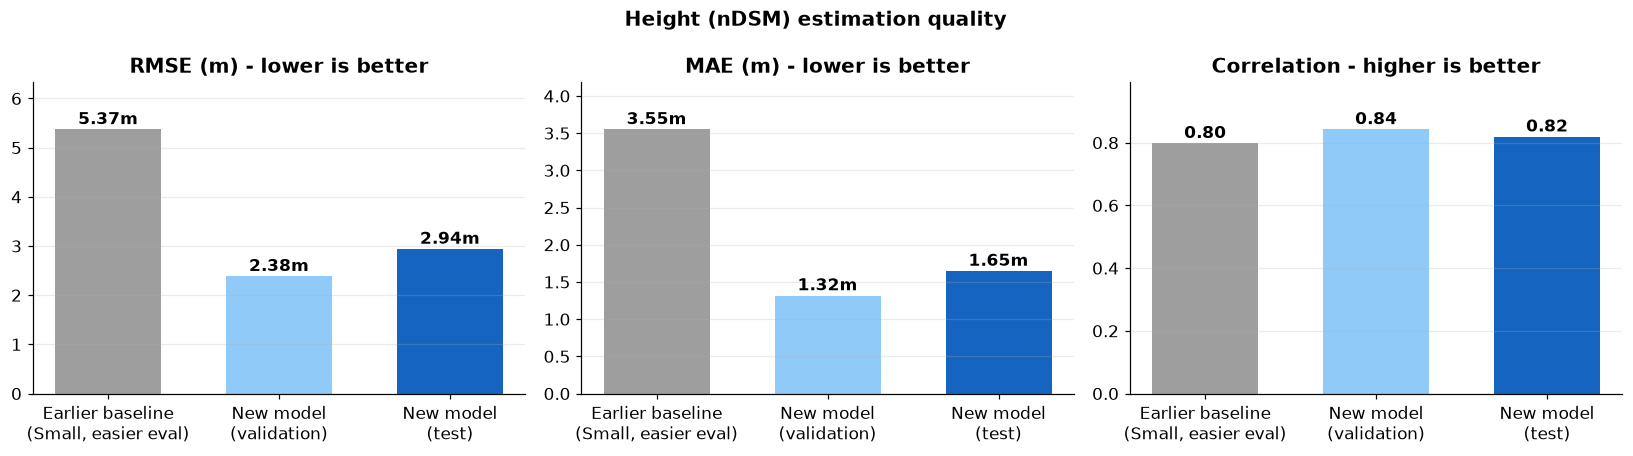

Height error improved 1.8x (RMSE) and 2.2x (MAE) vs the earlier baseline.


In [3]:
BASELINE = {"rmse": 5.37, "mae": 3.55, "correlation": 0.798}  # earlier single-task model (easier eval)

figure, axes = plt.subplots(1, 3, figsize=(15, 4.2))

panels = [
    ("RMSE (m) - lower is better", "rmse", "m", True),
    ("MAE (m) - lower is better", "mae", "m", True),
    ("Correlation - higher is better", "correlation", "", False),
]
for axis, (title, key, unit, lower_better) in zip(axes, panels):
    values = [BASELINE[key], validation[f"macro_{key}"], test[f"macro_{key}"]]
    bars = axis.bar(
        ["Earlier baseline\n(Small, easier eval)", "New model\n(validation)", "New model\n(test)"],
        values,
        color=["#9e9e9e", "#90caf9", "#1565c0"],
        width=0.62,
    )
    axis.set_title(title)
    axis.grid(alpha=0.25, axis="y")
    for bar, value in zip(bars, values):
        axis.text(bar.get_x() + bar.get_width() / 2, value + max(values) * 0.02,
                  f"{value:.2f}{unit}", ha="center", fontweight="bold", fontsize=11)
    axis.set_ylim(0, max(values) * 1.18)

figure.suptitle("Height (nDSM) estimation quality", fontweight="bold")
figure.tight_layout()
save(figure, "02_height_vs_baseline.png")
plt.show()

print(f"Height error improved {BASELINE['rmse'] / test['macro_rmse']:.1f}x (RMSE) and "
      f"{BASELINE['mae'] / test['macro_mae']:.1f}x (MAE) vs the earlier baseline.")


## 3. Semantic segmentation - per-class IoU

Overlap between predicted and true regions for each of the 7 GAMUS classes,
on held-out data. Building is the model's strongest class - exactly what the
demo renders.


saved: metrics_figures/03_per_class_iou.png


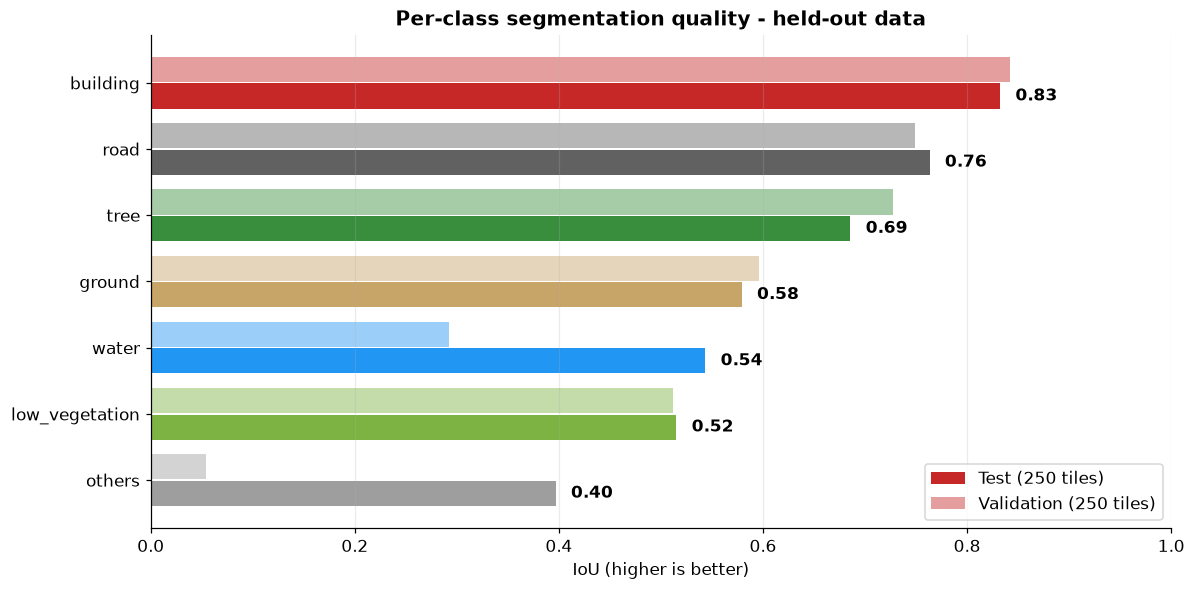

In [4]:
order = ["building", "road", "tree", "ground", "water", "low_vegetation", "others"]
test_iou = [test["per_class_iou"][name] for name in order]
val_iou = [validation["per_class_iou"][name] for name in order]
colors = [CLASS_COLORS[CLASS_NAMES.index(name)] for name in order]

figure, axis = plt.subplots(figsize=(11, 5.5))
y = np.arange(len(order))
axis.barh(y + 0.2, test_iou, height=0.38, color=colors, label="Test (250 tiles)")
axis.barh(y - 0.2, val_iou, height=0.38, color=colors, alpha=0.45, label="Validation (250 tiles)")
axis.set_yticks(y, order)
axis.invert_yaxis()
axis.set_xlabel("IoU (higher is better)")
axis.set_title("Per-class segmentation quality - held-out data")
axis.set_xlim(0, 1.0)
axis.grid(alpha=0.25, axis="x")
for index, value in enumerate(test_iou):
    axis.text(value + 0.015, index + 0.2, f"{value:.2f}", va="center", fontweight="bold", fontsize=11)
axis.legend(loc="lower right")
figure.tight_layout()
save(figure, "03_per_class_iou.png")
plt.show()


## 4. Building extraction - the demo's core capability

Building IoU and building boundary F1 measure what the demo actually shows:
correct building *footprints* and crisp building *outlines*.


saved: metrics_figures/04_building_metrics.png


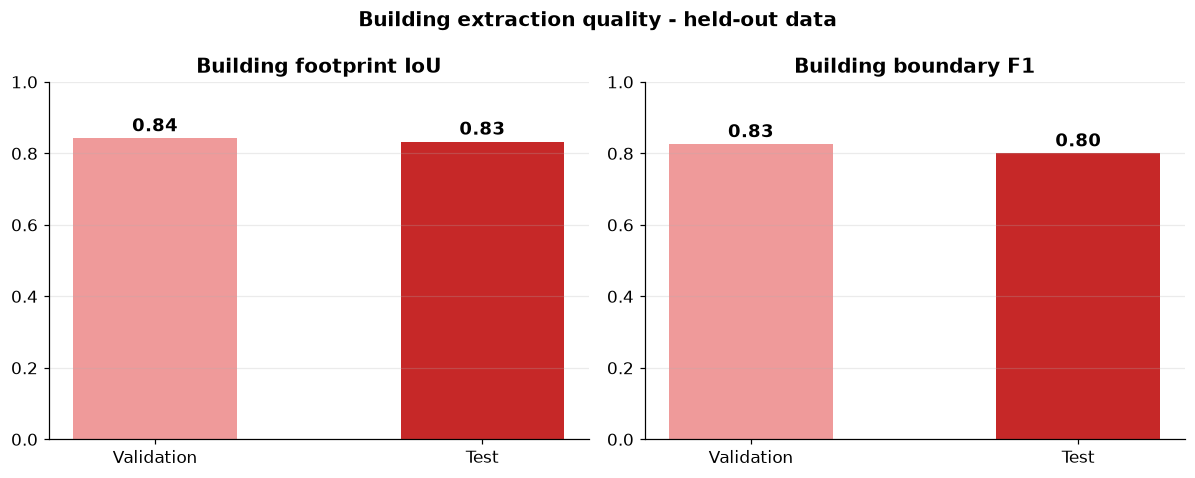

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.4))

for axis, (title, key, ylim) in zip(axes, [
    ("Building footprint IoU", "macro_building_iou", (0, 1.0)),
    ("Building boundary F1", "macro_building_boundary_f1", (0, 1.0)),
]):
    values = [validation[key], test[key]]
    bars = axis.bar(["Validation", "Test"], values, color=["#ef9a9a", "#c62828"], width=0.5)
    axis.set_title(title)
    axis.set_ylim(*ylim)
    axis.grid(alpha=0.25, axis="y")
    for bar, value in zip(bars, values):
        axis.text(bar.get_x() + bar.get_width() / 2, value + 0.02,
                  f"{value:.2f}", ha="center", fontweight="bold", fontsize=12)

figure.suptitle("Building extraction quality - held-out data", fontweight="bold")
figure.tight_layout()
save(figure, "04_building_metrics.png")
plt.show()


## 5. Capability profile (radar)

Validation vs test across all per-class IoUs - the overlap shows the model
generalizes consistently, not just to data it was tuned on.


saved: metrics_figures/05_capability_radar.png


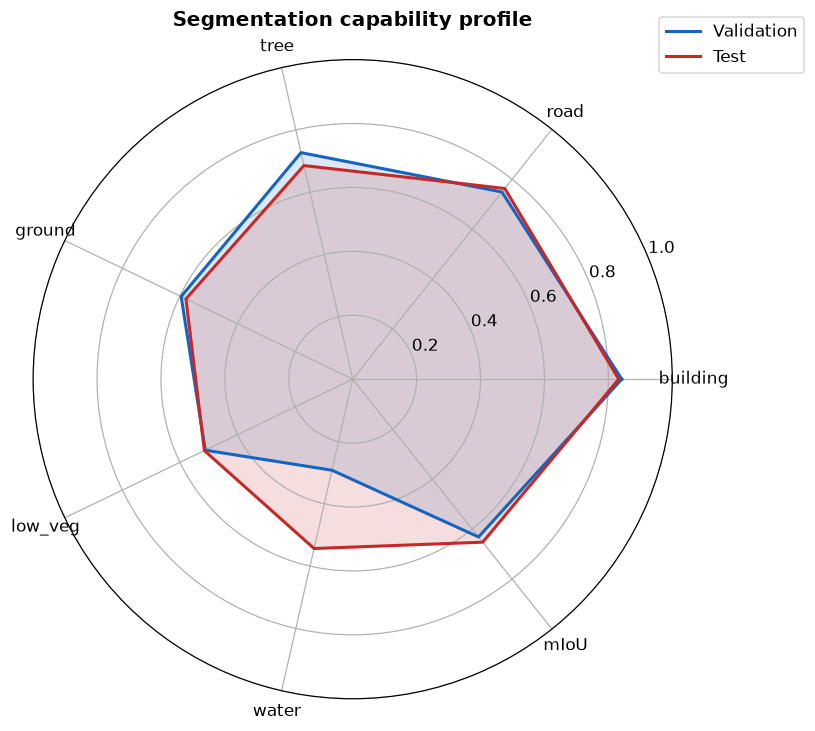

In [6]:
names = ["building", "road", "tree", "ground", "low_veg", "water", "mIoU"]
values_test = [test["per_class_iou"][n if n != "low_veg" else "low_vegetation"] for n in names[:-1]] + [test["macro_semantic_miou"]]
values_val = [validation["per_class_iou"][n if n != "low_veg" else "low_vegetation"] for n in names[:-1]] + [validation["macro_semantic_miou"]]

angles = np.linspace(0, 2 * np.pi, len(names), endpoint=False).tolist()
values_test += values_test[:1]
values_val += values_val[:1]
angles += angles[:1]

figure = plt.figure(figsize=(7.5, 7.5))
axis = figure.add_subplot(111, polar=True)
axis.plot(angles, values_val, color="#1565c0", lw=2, label="Validation")
axis.fill(angles, values_val, color="#1565c0", alpha=0.15)
axis.plot(angles, values_test, color="#c62828", lw=2, label="Test")
axis.fill(angles, values_test, color="#c62828", alpha=0.15)
axis.set_xticks(angles[:-1], names)
axis.set_ylim(0, 1.0)
axis.set_title("Segmentation capability profile", pad=22, fontweight="bold")
axis.legend(loc="upper right", bbox_to_anchor=(1.22, 1.08))
figure.tight_layout()
save(figure, "05_capability_radar.png")
plt.show()


## 6. Qualitative results

Side-by-side visual grids produced during evaluation (reference vs predicted).
Great as full-slide visuals for the demo.


saved: metrics_figures/06_qualitative_demo_report.png


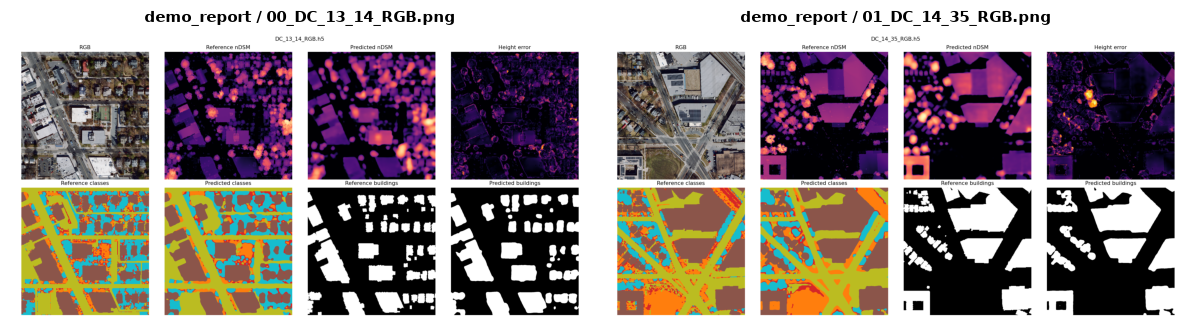

saved: metrics_figures/06_qualitative_test_visuals.png


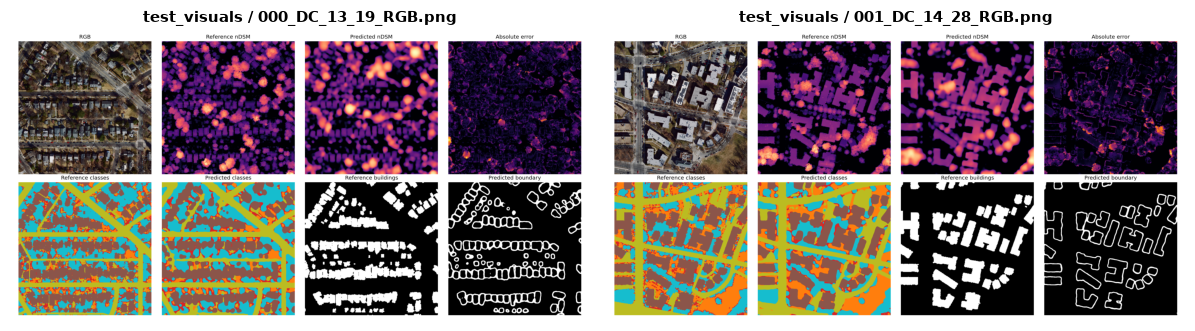

In [7]:
image_dirs = [
    ("demo_report", RUN_ROOT / "demo_report"),
    ("test_visuals", RUN_ROOT / "test_visuals"),
]
shown = 0
for label, directory in image_dirs:
    if not directory.is_dir() or shown >= 4:
        continue
    paths = sorted(directory.glob("*.png"))
    if not paths:
        continue
    count = min(2, 4 - shown)
    figure, axes = plt.subplots(1, count, figsize=(11 * count / 2, 5.5))
    axes = np.atleast_1d(axes)
    for axis, path in zip(axes, paths[:count]):
        axis.imshow(mpimg.imread(path))
        axis.axis("off")
        axis.set_title(f"{label} / {path.name}", fontsize=10)
    figure.tight_layout()
    save(figure, f"06_qualitative_{label}.png")
    plt.show()
    shown += count

if shown == 0:
    print("No qualitative visuals found in the run directory.")


## 7. Training data & class-imbalance handling

The 2,400 training tiles contain ~2.5 billion labeled pixels with a severe class
imbalance (trees cover ~5x more pixels than water). The trainer compensates with
sqrt-inverse-frequency class weights, clipped to [0.5, 3.0], so rare classes
survive training - which is why water reaches 0.54 IoU despite being rare.


In [ ]:
histogram = json.loads((RUN_ROOT / "class_histogram.json").read_text())
counts = np.asarray(histogram["counts"], dtype=np.float64)
weights = np.asarray(histogram["weights"], dtype=np.float64)
total_pixels = counts.sum()

figure, axes = plt.subplots(1, 2, figsize=(14, 4.8))

bars = axes[0].bar(CLASS_NAMES, counts, color=CLASS_COLORS, width=0.62)
axes[0].set_yscale("log")
axes[0].set_title(f"Training pixels per class ({total_pixels / 1e9:.2f} billion total, log scale)")
axes[0].set_ylabel("Pixel count (log)")
axes[0].grid(alpha=0.25, axis="y")
axes[0].tick_params(axis="x", rotation=25)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, count * 1.15,
                 f"{count / 1e6:.0f}M", ha="center", fontsize=10, fontweight="bold")

axes[1].bar(CLASS_NAMES, weights, color=CLASS_COLORS, width=0.62)
axes[1].axhline(1.0, color="#616161", ls=":", lw=1)
axes[1].axhline(0.5, color="#f57c00", ls="--", lw=1, alpha=0.7)
axes[1].axhline(3.0, color="#f57c00", ls="--", lw=1, alpha=0.7)
axes[1].set_title("Class weights applied in the loss (clipped to [0.5, 3.0])")
axes[1].set_ylabel("Weight")
axes[1].set_ylim(0, 3.4)
axes[1].grid(alpha=0.25, axis="y")
axes[1].tick_params(axis="x", rotation=25)
for bar, weight in zip(bars, weights):
    axes[1].text(bar.get_x() + bar.get_width() / 2, weight + 0.08,
                 f"{weight:.2f}", ha="center", fontsize=10, fontweight="bold")

figure.suptitle("Class imbalance in GAMUS and its correction", fontweight="bold")
figure.tight_layout()
save(figure, "07_dataset_imbalance.png")
plt.show()


## 8. Multitask training dynamics

All five loss components across the 10 epochs (log scale). The task-weight ramp
over the first two epochs and the backbone unfreezing at epoch 1 are both
visible; every component converges smoothly with no instability - the reward of
grad warmup + clipping + the loss ramp design.


In [ ]:
components = ["height", "gradient", "log", "semantic", "boundary"]
colors = {"height": "#1565c0", "gradient": "#00897b", "log": "#8e24aa",
          "semantic": "#c62828", "boundary": "#f57c00"}

figure, axis = plt.subplots(figsize=(11, 5))
for component in components:
    values = [entry["losses"][component] for entry in history]
    axis.plot(epochs, values, marker="o", lw=2, color=colors[component],
              label=component.replace("log", "log-height"))
axis.set_yscale("log")
axis.set_ylim(0.01, 4)
axis.set_xlabel("Epoch")
axis.set_ylabel("Loss component (log scale)")
axis.set_title("Multitask loss components over training")
axis.grid(alpha=0.25, which="both")
axis.axvspan(1, 2, color="#fdd835", alpha=0.18)
axis.text(1.5, 3.4, "task-weight ramp", ha="center", fontsize=9, color="#9e7c0c")
axis.legend(ncol=5, loc="lower left", framealpha=0.9)
figure.tight_layout()
save(figure, "08_loss_dynamics.png")
plt.show()


## 9. Per-tile height error - distribution, not just an average

Averages hide outliers. Across all 250 held-out test tiles: the median tile has
just ~2.3 m RMSE, and 90% of tiles are under ~5 m. The long tail (worst tiles)
is where hard scenes live - dense vegetation and unusual roof structures.


In [ ]:
test_samples = test["per_sample"]
tile_rmse = np.asarray([record["rmse"] for record in test_samples], dtype=np.float64)
median_rmse = float(np.median(tile_rmse))
p90_rmse = float(np.percentile(tile_rmse, 90))

figure, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].hist(tile_rmse, bins=30, color="#1565c0", alpha=0.85, edgecolor="white")
axes[0].axvline(median_rmse, color="#2e7d32", ls="--", lw=2,
                label=f"median = {median_rmse:.2f} m")
axes[0].axvline(p90_rmse, color="#c62828", ls="--", lw=2,
                label=f"90% of tiles < {p90_rmse:.2f} m")
axes[0].set_title("Per-tile height RMSE distribution (test)")
axes[0].set_xlabel("RMSE (m)")
axes[0].set_ylabel("Tiles")
axes[0].legend()
axes[0].grid(alpha=0.25, axis="y")

sorted_rmse = np.sort(tile_rmse)
ecdf = np.arange(1, len(sorted_rmse) + 1) / len(sorted_rmse)
axes[1].plot(sorted_rmse, ecdf, color="#1565c0", lw=2.5)
axes[1].axvline(median_rmse, color="#2e7d32", ls="--", lw=1.5)
axes[1].axvline(p90_rmse, color="#c62828", ls="--", lw=1.5)
axes[1].plot([median_rmse], [0.5], "o", color="#2e7d32", markersize=8)
axes[1].plot([p90_rmse], [0.9], "o", color="#c62828", markersize=8)
axes[1].annotate(f"median {median_rmse:.2f} m", xy=(median_rmse, 0.5),
                 xytext=(median_rmse + 2.2, 0.42), fontsize=10,
                 arrowprops=dict(arrowstyle="->", color="#2e7d32"))
axes[1].annotate(f"90th pct {p90_rmse:.2f} m", xy=(p90_rmse, 0.9),
                 xytext=(p90_rmse + 2.2, 0.80), fontsize=10,
                 arrowprops=dict(arrowstyle="->", color="#c62828"))
axes[1].set_title("Cumulative distribution (ECDF)")
axes[1].set_xlabel("Per-tile RMSE (m)")
axes[1].set_ylabel("Fraction of tiles")
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.25)

figure.suptitle("Height error is consistently low across held-out tiles", fontweight="bold")
figure.tight_layout()
save(figure, "09_error_distribution.png")
plt.show()

print(f"median {median_rmse:.2f} m | mean {tile_rmse.mean():.2f} m | 90th pct {p90_rmse:.2f} m | worst tile {tile_rmse.max():.2f} m")


## 10. Per-class IoU - full distribution across tiles

Box plots of per-tile IoU for every class (each distribution = up to 250 tiles).
High, tight boxes mean the class is reliably segmented everywhere - not just on
average. Building is both the best and one of the most consistent classes.


In [ ]:
per_tile = {}
for name in CLASS_NAMES:
    values = [record["per_class_iou"].get(name) for record in test_samples]
    per_tile[name] = np.asarray([value for value in values if value is not None], dtype=np.float64)

order = sorted(CLASS_NAMES, key=lambda name: -np.median(per_tile[name]))
data = [per_tile[name] for name in order]
box_colors = [CLASS_COLORS[CLASS_NAMES.index(name)] for name in order]
tile_counts = [len(per_tile[name]) for name in order]

figure, axis = plt.subplots(figsize=(12, 5.8))
boxes = axis.boxplot(data, positions=np.arange(1, len(order) + 1),
                     showfliers=False, patch_artist=True, widths=0.5,
                     medianprops=dict(color="black", lw=2))
for patch, color in zip(boxes["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
rng = np.random.default_rng(7)
for position, (values, color) in enumerate(zip(data, box_colors), start=1):
    jitter = rng.normal(position, 0.055, size=len(values))
    axis.scatter(jitter, values, s=9, alpha=0.30, color=color, zorder=3)
    median = float(np.median(values))
    axis.text(position + 0.32, median, f"{median:.2f}", va="center", fontsize=10, fontweight="bold")

axis.set_xticks(np.arange(1, len(order) + 1))
axis.set_xticklabels([f"{name}\n({count} tiles)" for name, count in zip(order, tile_counts)],
                     rotation=20, ha="right")
axis.set_ylabel("Per-tile IoU")
axis.set_ylim(0, 1.02)
axis.set_title("Per-class segmentation quality - distribution across 250 test tiles")
axis.grid(alpha=0.25, axis="y")
figure.tight_layout()
save(figure, "10_per_class_iou_distribution.png")
plt.show()


## 11. Building extraction - per-tile deep dive

Every test tile that contains buildings, individually. Left: the distribution of
building IoU per tile. Right: footprint quality (IoU) vs outline quality
(boundary F1) per tile - the two move together, meaning the model captures
building *shapes* correctly, not just approximate blobs.


In [ ]:
building_tiles = [record for record in test_samples if record["building_iou"] is not None]
building_ious = np.asarray([record["building_iou"] for record in building_tiles], dtype=np.float64)
boundary_f1s = np.asarray([record["building_boundary_f1"] for record in building_tiles], dtype=np.float64)
no_building = len(test_samples) - len(building_tiles)

figure, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(building_ious, bins=25, color="#c62828", alpha=0.85, edgecolor="white")
axes[0].axvline(float(np.median(building_ious)), color="#1565c0", ls="--", lw=2,
                label=f"median = {np.median(building_ious):.2f}")
axes[0].set_title(f"Building IoU per tile ({len(building_tiles)} tiles with buildings)")
axes[0].set_xlabel("Building IoU")
axes[0].set_ylabel("Tiles")
axes[0].legend()
axes[0].grid(alpha=0.25, axis="y")

axes[1].scatter(building_ious, boundary_f1s, s=22, alpha=0.55, color="#6a1b9a", edgecolors="none")
axes[1].plot([0, 1], [0, 1], ls=":", color="#9e9e9e", lw=1.2)
axes[1].set_xlabel("Building IoU (footprint overlap)")
axes[1].set_ylabel("Building boundary F1 (outline precision)")
axes[1].set_title("Footprint quality vs outline quality")
axes[1].set_xlim(0, 1.02)
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.25)
correlation = float(np.corrcoef(building_ious, boundary_f1s)[0, 1])
axes[1].text(0.03, 0.95, f"r = {correlation:.2f}", transform=axes[1].transAxes,
             fontsize=11, fontweight="bold")

figure.suptitle("Buildings are segmented accurately tile-by-tile", fontweight="bold")
figure.tight_layout()
save(figure, "11_building_deep_dive.png")
plt.show()

above_half = float(np.mean(building_ious >= 0.5))
print(f"{len(building_tiles)}/{len(test_samples)} test tiles contain buildings "
      f"({no_building} without); median building IoU {np.median(building_ious):.2f}; "
      f"{above_half:.0%} of building tiles have IoU >= 0.5")


In [8]:
rows = [
    ("Height RMSE (m)", validation["macro_rmse"], test["macro_rmse"], "lower better"),
    ("Height MAE (m)", validation["macro_mae"], test["macro_mae"], "lower better"),
    ("Height correlation (r)", validation["macro_correlation"], test["macro_correlation"], "higher better"),
    ("Semantic mIoU", validation["macro_semantic_miou"], test["macro_semantic_miou"], "higher better"),
    ("Building IoU", validation["macro_building_iou"], test["macro_building_iou"], "higher better"),
    ("Building boundary F1", validation["macro_building_boundary_f1"], test["macro_building_boundary_f1"], "higher better"),
    ("Boundary head F1", validation["macro_boundary_f1"], test["macro_boundary_f1"], "higher better"),
]
per_class = [(f"IoU: {name}", validation["per_class_iou"][name], test["per_class_iou"][name], "higher better")
             for name in ["building", "road", "tree", "ground", "water", "low_vegetation", "others"]]

header = f"| {'Metric':<26} | {'Validation (250)':>17} | {'Test (250)':>12} | {'':>14} |"
divider = "|" + "-" * 28 + "|" + "-" * 19 + "|" + "-" * 14 + "|" + "-" * 16 + "|"
print(header)
print(divider)
for name, value_val, value_test, note in rows + per_class:
    print(f"| {name:<26} | {value_val:>17.4f} | {value_test:>12.4f} | {note:>14} |")

print()
print("Copy-paste summary line for the PPT:")
print(f'  "Fine-tuned Depth Anything V2 Base with a DPT multitask decoder on 2,400 GAMUS tiles:')
print(f'   height RMSE {test["macro_rmse"]:.2f} m (r={test["macro_correlation"]:.2f}), building IoU '
      f'{test["macro_building_iou"]:.2f}, boundary F1 {test["macro_building_boundary_f1"]:.2f} - on held-out test data."')


| Metric                     |  Validation (250) |   Test (250) |                |
|----------------------------|-------------------|--------------|----------------|
| Height RMSE (m)            |            2.3841 |       2.9383 |   lower better |
| Height MAE (m)             |            1.3169 |       1.6465 |   lower better |
| Height correlation (r)     |            0.8421 |       0.8188 |  higher better |
| Semantic mIoU              |            0.6315 |       0.6524 |  higher better |
| Building IoU               |            0.8419 |       0.8324 |  higher better |
| Building boundary F1       |            0.8253 |       0.7997 |  higher better |
| Boundary head F1           |            0.1917 |       0.1848 |  higher better |
| IoU: building              |            0.8419 |       0.8324 |  higher better |
| IoU: road                  |            0.7491 |       0.7633 |  higher better |
| IoU: tree                  |            0.7272 |       0.6857 |  higher better |
| Io

## 12. Base Depth Anything V2 vs. fine-tuned Dharvi

This section evaluates both models on the same GAMUS test samples. Because the base model produces relative depth, its scale and offset are fitted on validation data only; the held-out test split is used for the final comparison.


In [ ]:
# Configure paths and load the same GAMUS samples for both models.
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image

GAMUS_ROOT = Path(os.getenv("GAMUS_ROOT", "/kaggle/input/gamus"))
DHARVI_CHECKPOINT = Path(os.getenv("DHARVI_CHECKPOINT", "dharvi.pth"))
BASE_MODEL_ID = os.getenv("BASE_DEPTH_MODEL", "depth-anything/Depth-Anything-V2-Base-hf")
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
TILE_SIZE, TILE_OVERLAP = 518, 0.5
MAX_TEST_SAMPLES = None  # Set an integer for a quick smoke test.

if not GAMUS_ROOT.exists():
    raise FileNotFoundError(f"GAMUS_ROOT does not exist: {GAMUS_ROOT}")
if not DHARVI_CHECKPOINT.exists():
    raise FileNotFoundError(f"Set DHARVI_CHECKPOINT to Dharvi's .pth file: {DHARVI_CHECKPOINT}")

for candidate in (Path.cwd(), Path.cwd() / "backend"):
    if (candidate / "training").is_dir():
        sys.path.insert(0, str(candidate))

from training.kaggle_final_train import index_samples, load_triplet, tiled_predict

GAMUS_KEYS = {
    "image": os.getenv("GAMUS_IMAGE_KEY", "image"),
    "height": os.getenv("GAMUS_HEIGHT_KEY", "image"),
    "classes": os.getenv("GAMUS_CLASS_KEY", "image"),
}
samples = index_samples(GAMUS_ROOT)
test_samples = samples["test"][:MAX_TEST_SAMPLES] if MAX_TEST_SAMPLES else samples["test"]
print(f"Device: {DEVICE} | validation: {len(samples['val'])} | test: {len(test_samples)}")


In [ ]:
# Load the pretrained base model and the fine-tuned Dharvi checkpoint.
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
from training.depthwizard_model import build_depthwizard_model

processor = AutoImageProcessor.from_pretrained(BASE_MODEL_ID)
base_model = AutoModelForDepthEstimation.from_pretrained(BASE_MODEL_ID).to(DEVICE).eval()

checkpoint = torch.load(DHARVI_CHECKPOINT, map_location="cpu", weights_only=False)
state_dict = checkpoint.get("state_dict", checkpoint) if isinstance(checkpoint, dict) else checkpoint
model_id = checkpoint.get("model_id", BASE_MODEL_ID) if isinstance(checkpoint, dict) else BASE_MODEL_ID
dharvi = build_depthwizard_model(model_id)
missing, unexpected = dharvi.load_state_dict(state_dict, strict=False)
if missing or unexpected:
    print(f"Checkpoint differences: missing={len(missing)}, unexpected={len(unexpected)}")
dharvi = dharvi.to(DEVICE).eval()

def _positions(length):
    step = max(1, int(TILE_SIZE * (1 - TILE_OVERLAP)))
    values = list(range(0, max(length - TILE_SIZE, 0) + 1, step))
    return sorted(set(values + [max(length - TILE_SIZE, 0)]))

def predict_base(image):
    array = np.asarray(image.convert("RGB"))
    height, width = array.shape[:2]
    total, weights = np.zeros((height, width), np.float32), np.zeros((height, width), np.float32)
    with torch.inference_mode():
        for top in _positions(height):
            for left in _positions(width):
                crop = array[top:top + TILE_SIZE, left:left + TILE_SIZE]
                def run(tile):
                    inputs = processor(images=Image.fromarray(tile), return_tensors="pt")
                    inputs = {key: value.to(DEVICE) for key, value in inputs.items()}
                    output = base_model(**inputs).predicted_depth.unsqueeze(1)
                    return torch.nn.functional.interpolate(output, size=tile.shape[:2], mode="bilinear", align_corners=False)[0, 0].cpu().numpy()
                prediction = run(crop).astype(np.float32)
                prediction = 0.5 * (prediction + run(np.ascontiguousarray(crop[:, ::-1]))[:, ::-1])
                total[top:top + prediction.shape[0], left:left + prediction.shape[1]] += prediction
                weights[top:top + prediction.shape[0], left:left + prediction.shape[1]] += 1
    return total / np.maximum(weights, 1e-6)

def predict_dharvi(image):
    height, _, _ = tiled_predict(
        dharvi, np.asarray(image.convert("RGB")), torch.device(DEVICE),
        TILE_SIZE, TILE_OVERLAP, float(checkpoint.get("height_scale", 1.0)),
    )
    return height.astype(np.float32)

def metric(predicted, target, valid):
    mask = valid & np.isfinite(predicted) & np.isfinite(target)
    error = predicted[mask] - target[mask]
    return {
        "rmse_m": float(np.sqrt(np.mean(error ** 2))),
        "mae_m": float(np.mean(np.abs(error))),
        "correlation": float(np.corrcoef(predicted[mask], target[mask])[0, 1])
            if mask.sum() > 1 and np.std(predicted[mask]) > 1e-8 and np.std(target[mask]) > 1e-8 else 0.0,
    }

def fit_affine(predictions, targets, valids):
    x = np.concatenate([prediction[valid].ravel() for prediction, valid in zip(predictions, valids)])
    y = np.concatenate([target[valid].ravel() for target, valid in zip(targets, valids)])
    scale, offset = np.linalg.lstsq(np.column_stack([x, np.ones_like(x)]), y, rcond=None)[0]
    return float(scale), float(offset)

print("Models loaded.")


In [ ]:
# Calibrate only the base model's arbitrary relative-depth scale on validation data.
val_predictions, val_targets, val_valids = [], [], []
for sample in samples["val"]:
    image, target, _, valid = load_triplet(sample, GAMUS_KEYS)
    val_predictions.append(predict_base(Image.fromarray(image)))
    val_targets.append(target.astype(np.float32))
    val_valids.append(valid)

base_scale, base_offset = fit_affine(val_predictions, val_targets, val_valids)
print(f"Base calibration: target = {base_scale:.6f} * depth + {base_offset:.6f}")


In [ ]:
# Evaluate both models on identical held-out test samples.
rows = []
for index, sample in enumerate(test_samples, start=1):
    image, target, _, valid = load_triplet(sample, GAMUS_KEYS)
    image = Image.fromarray(image)
    base_prediction = base_scale * predict_base(image) + base_offset
    dharvi_prediction = predict_dharvi(image)

    rows += [
        {"model": "Base Depth Anything V2", **metric(base_prediction, target, valid)},
        {"model": "Dharvi fine-tuned", **metric(dharvi_prediction, target, valid)},
    ]
    if index % 10 == 0 or index == len(test_samples):
        print(f"Evaluated {index}/{len(test_samples)}")

comparison = pd.DataFrame(rows)
summary = comparison.groupby("model")[["rmse_m", "mae_m", "correlation"]].mean().sort_values("rmse_m")
display(summary.style.format({"rmse_m": "{:.3f}", "mae_m": "{:.3f}", "correlation": "{:.3f}"}))


In [ ]:
# PPT-ready chart and summary.
figure, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = {"Base Depth Anything V2": "#9e9e9e", "Dharvi fine-tuned": "#1565c0"}
for axis, name, title in zip(
    axes, ["rmse_m", "mae_m", "correlation"],
    ["RMSE (m) — lower is better", "MAE (m) — lower is better", "Correlation — higher is better"],
):
    values = summary[name]
    bars = axis.bar(values.index, values.values, color=[colors[key] for key in values.index], width=0.58)
    axis.set_title(title)
    axis.grid(axis="y", alpha=0.25)
    axis.tick_params(axis="x", rotation=18)
    for bar, value in zip(bars, values.values):
        axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:.3f}",
                  ha="center", va="bottom", fontweight="bold")
figure.suptitle("Base Depth Anything V2 vs. Dharvi — held-out GAMUS test set", fontweight="bold")
figure.tight_layout()
save(figure, "12_base_vs_dharvi_height_metrics.png")
plt.show()

for model, row in summary.iterrows():
    print(f"{model}: RMSE={row.rmse_m:.2f} m | MAE={row.mae_m:.2f} m | r={row.correlation:.3f}")
